In [1]:
# ================================================================
# EXTRAÇÃO DE PARALELEPÍPEDO 3D + MOSAICO + HISTOGRAMA + GAUSSIANA
# ================================================================
#
# Este código pressupõe que:
#
#     imgFDK
#
# já exista e seja uma imagem 3D reconstruída pelo TIGRE.
#
# Estrutura:
#
#     imgFDK[z, y, x]
#
# Fluxo:
#
#     1) Escolher uma fatia Z
#     2) Desenhar um retângulo sobre a região de interesse
#     3) Obter Xmin, Xmax, Ymin, Ymax
#     4) Escolher Z inicial e Z final
#     5) Extrair o paralelepípedo
#     6) Visualizar várias fatias da ROI em mosaico
#     7) Gerar histograma dos valores CT
#     8) Ajustar uma Gaussiana
#     9) Obter μ e σ da região
#
# ================================================================

In [3]:
# Importar bibliotecas
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
from matplotlib.widgets import Slider
import numpy as np
import tigre
import tigre.algorithms as algs



import numpy as np
import matplotlib.pyplot as plt

from matplotlib.widgets import RectangleSelector
from scipy.optimize import curve_fit


In [4]:
# Carregar projeções
projs = np.load(
    "/mnt/d/Iniciacao_cientifica/head_phantom/imagens_raw2/sinoAula2.npz"
)

projs = projs["sino"]

projs_ln = -np.log(projs/1.0)

#%% Definir a geometria 
geo = tigre.geometry_default(high_resolution=True)

print("Projeções:", projs.shape)

Projeções: (719, 1024, 1024)


In [5]:
count = (projs_ln < 0).sum()
total = projs_ln.size
print(f'Projeções com valores negativos: {count} de {total} ({count/total:.2%})')

projs_ln [projs_ln < 0] = 0

Projeções com valores negativos: 45299903 de 753926144 (6.01%)


In [ ]:
#%% Definir a geometria 
geo = tigre.geometry_default(high_resolution=True)

print("Projeções:", projs.shape)

Projeções: (719, 1024, 1024)


In [6]:
# ============================================================
# GEOMETRIA TIGRE
# ============================================================

geo = tigre.geometry_default(high_resolution=True)

# Distâncias
geo.DSD = 1150   # mm
geo.DSO = 1000   # mm



In [7]:
# Detector
geo.nDetector = np.array([1024, 1024])
geo.dDetector = np.array([0.3, 0.3])
geo.sDetector = (
    geo.nDetector * geo.dDetector
)

# Volume reconstruído
geo.nVoxel = np.array([384, 400, 400])
geo.sVoxel = np.array([240, 250, 250])
geo.dVoxel = (
    geo.sVoxel / geo.nVoxel
)

geo.accuracy = 0.5

In [8]:
angles = np.linspace(0, 360, 719, endpoint=False, dtype=np.float32)
print(angles)
angles = np.deg2rad(angles)
print(angles)

[  0.          0.5006954   1.0013908   1.5020863   2.0027816   2.503477
   3.0041726   3.5048678   4.0055633   4.5062585   5.006954    5.5076494
   6.008345    6.5090404   7.0097356   7.5104313   8.0111265   8.511822
   9.012517    9.513213   10.013908   10.514604   11.015299   11.515994
  12.01669    12.5173855  13.018081   13.518776   14.019471   14.520167
  15.020863   15.521558   16.022253   16.52295    17.023643   17.52434
  18.025034   18.52573    19.026426   19.52712    20.027817   20.528511
  21.029207   21.529903   22.030598   22.531294   23.031988   23.532684
  24.03338    24.534075   25.034771   25.535465   26.036161   26.536858
  27.037552   27.538248   28.038942   28.539639   29.040335   29.541029
  30.041725   30.54242    31.043116   31.543812   32.044506   32.5452
  33.0459     33.546593   34.047287   34.547985   35.04868    35.549374
  36.050068   36.550766   37.05146    37.552155   38.052853   38.553547
  39.05424    39.55494    40.055634   40.556328   41.057022   41.5

In [9]:
# ================================================================
# 1. VERIFICAR A IMAGEM
# ================================================================

imgFDK = algs.fdk(projs_ln, geo, angles,filter="hann")



In [10]:


print("\nValor mínimo:")
print(imgFDK.min())

print("\nValor máximo:")
print(imgFDK.max())

print("\nValor médio:")
print(imgFDK.mean())


Valor mínimo:
-0.009420291

Valor máximo:
0.043773487

Valor médio:
0.008482084


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plotVolume3Views(
    vol, title=None, axial=None, coronal=None, sagittal=None,
    cmap='gray', vmin=None, vmax=None, tick_step=10
):

    nz, ny, nx = vol.shape

    axial = nz//2 if axial is None else axial
    coronal = ny//2 if coronal is None else coronal
    sagittal = nx//2 if sagittal is None else sagittal

    vmin = vol.min() if vmin is None else vmin
    vmax = vol.max() if vmax is None else vmax

    fig, ax = plt.subplots(3, 1, figsize=(10, 20))

    # Imagens
    imgs = [
        vol[axial, :, :],
        vol[:, coronal, :],
        vol[:, :, sagittal]
    ]

    titles = [
        f'Axial — Z = {axial}',
        f'Coronal — Y = {coronal}',
        f'Sagital — X = {sagittal}'
    ]

    labels = [
        ('X — coluna', 'Y — linha'),
        ('X — coluna', 'Z — linha'),
        ('Y — coluna', 'Z — linha')
    ]

    # Mostrar as três vistas
    for a, img, t, (xlabel, ylabel) in zip(ax, imgs, titles, labels):

        a.imshow(
            img,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            origin='upper'
        )

        a.set_title(t, fontsize=12)
        a.set_xlabel(xlabel)
        a.set_ylabel(ylabel)

        a.set_xticks(np.arange(0, img.shape[1], tick_step))
        a.set_yticks(np.arange(0, img.shape[0], tick_step))

        a.tick_params(axis='x', rotation=45, labelsize=8)
        a.tick_params(axis='y', labelsize=8)

        a.grid(True, linewidth=0.4, alpha=0.4, color='red')



    if title:
        fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

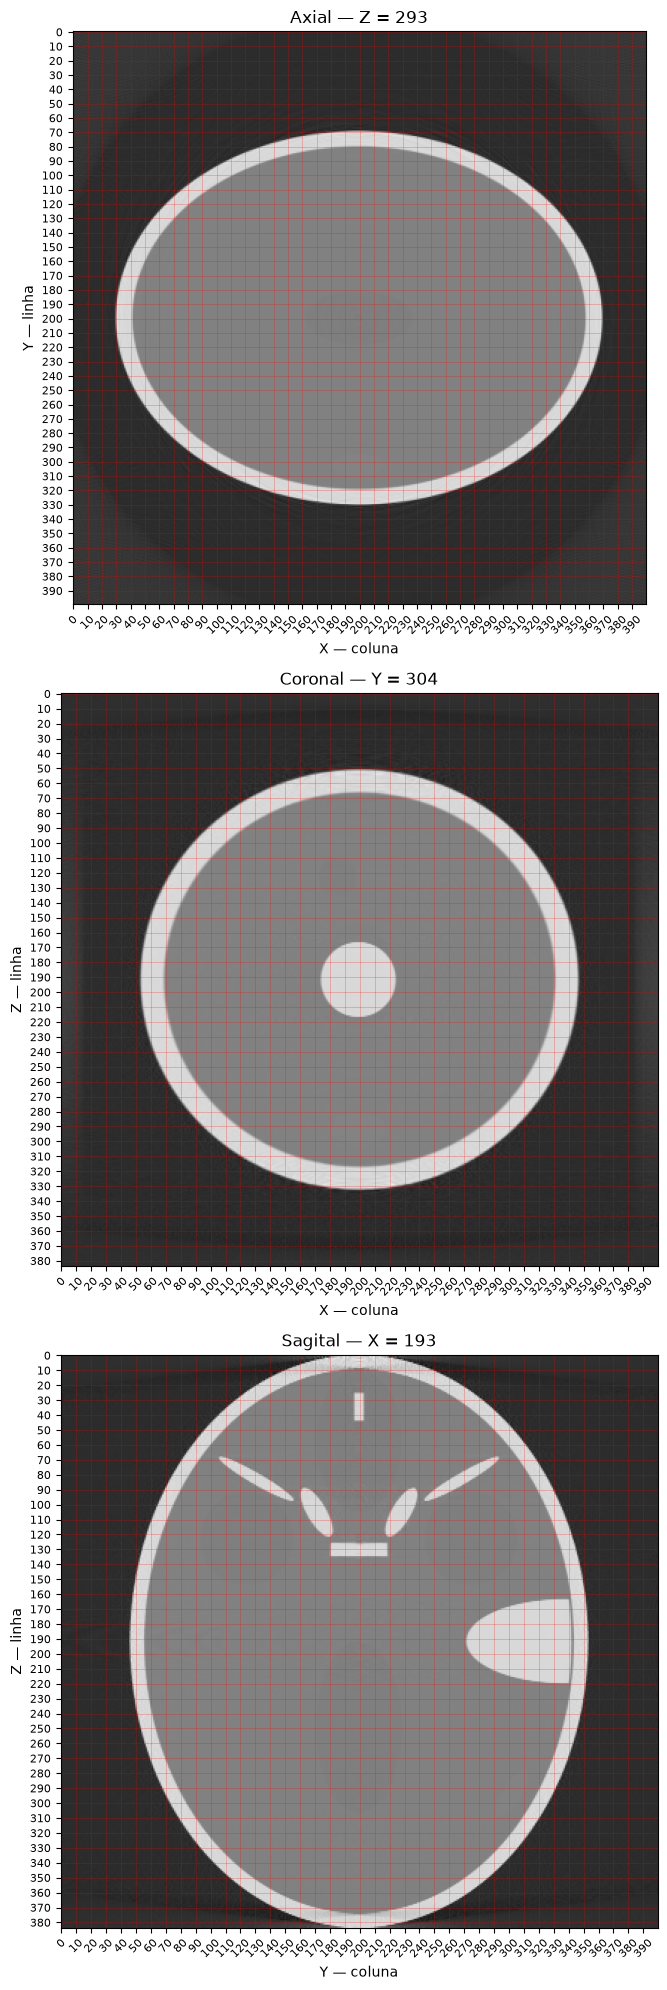

In [63]:
plotVolume3Views(
    imgFDK,
    title='',
    axial=293,
    coronal=304,
    sagittal=193
)

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def createRectMasks6Materials(vol, rois, show=True):

    masks = {}

    # =========================================================
    # CRIAÇÃO DAS MÁSCARAS
    # =========================================================

    for material, r in rois.items():

        x0, x1 = r['x']
        y0, y1 = r['y']
        z0, z1 = r['z']

        mask = np.zeros_like(vol, dtype=np.uint8)

        # vol[z, y, x]
        mask[z0:z1, y0:y1, x0:x1] = 1

        masks[material] = mask

    # =========================================================
    # VISUALIZAÇÃO
    # =========================================================

    if show:

        fig, ax = plt.subplots(
            6, 3,
            figsize=(9, 18)
        )

        for i, (material, r) in enumerate(rois.items()):

            x0, x1 = r['x']
            y0, y1 = r['y']
            z0, z1 = r['z']

            # Centro da ROI
            z = (z0 + z1) // 2
            y = (y0 + y1) // 2
            x = (x0 + x1) // 2

            # -------------------------------------------------
            # AXIAL
            # -------------------------------------------------

            ax[i, 0].imshow(
                vol[z, :, :],
                cmap='gray'
            )

            ax[i, 0].add_patch(
                patches.Rectangle(
                    (x0, y0),
                    x1 - x0,
                    y1 - y0,
                    fill=False,
                    edgecolor='red',
                    linewidth=1.5
                )
            )

            ax[i, 0].set_title(
                f'{material} - Axial (Z={z})',
                fontsize=9
            )

            ax[i, 0].set_xlabel('X', fontsize=8)
            ax[i, 0].set_ylabel('Y', fontsize=8)

            # -------------------------------------------------
            # CORONAL
            # -------------------------------------------------

            ax[i, 1].imshow(
                vol[:, y, :],
                cmap='gray'
            )

            ax[i, 1].add_patch(
                patches.Rectangle(
                    (x0, z0),
                    x1 - x0,
                    z1 - z0,
                    fill=False,
                    edgecolor='red',
                    linewidth=1.5
                )
            )

            ax[i, 1].set_title(
                f'{material} - Coronal (Y={y})',
                fontsize=9
            )

            ax[i, 1].set_xlabel('X', fontsize=8)
            ax[i, 1].set_ylabel('Z', fontsize=8)

            # -------------------------------------------------
            # SAGITAL
            # -------------------------------------------------

            ax[i, 2].imshow(
                vol[:, :, x],
                cmap='gray'
            )

            ax[i, 2].add_patch(
                patches.Rectangle(
                    (y0, z0),
                    y1 - y0,
                    z1 - z0,
                    fill=False,
                    edgecolor='red',
                    linewidth=1.5
                )
            )

            ax[i, 2].set_title(
                f'{material} - Sagital (X={x})',
                fontsize=9
            )

            ax[i, 2].set_xlabel('Y', fontsize=8)
            ax[i, 2].set_ylabel('Z', fontsize=8)

            # -------------------------------------------------
            # GRID
            # -------------------------------------------------

            for j in range(3):
                ax[i, j].grid(
                    True,
                    color='red',
                    alpha=0.3,
                    linewidth=0.4
                )

        # =====================================================
        # TÍTULOS DAS COLUNAS
        # =====================================================

        fig.text(
            0.22, 0.995,
            'AXIAL',
            ha='center',
            va='top',
            fontsize=12,
            fontweight='bold'
        )

        fig.text(
            0.50, 0.995,
            'CORONAL',
            ha='center',
            va='top',
            fontsize=12,
            fontweight='bold'
        )

        fig.text(
            0.78, 0.995,
            'SAGITAL',
            ha='center',
            va='top',
            fontsize=12,
            fontweight='bold'
        )

        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()

    return masks

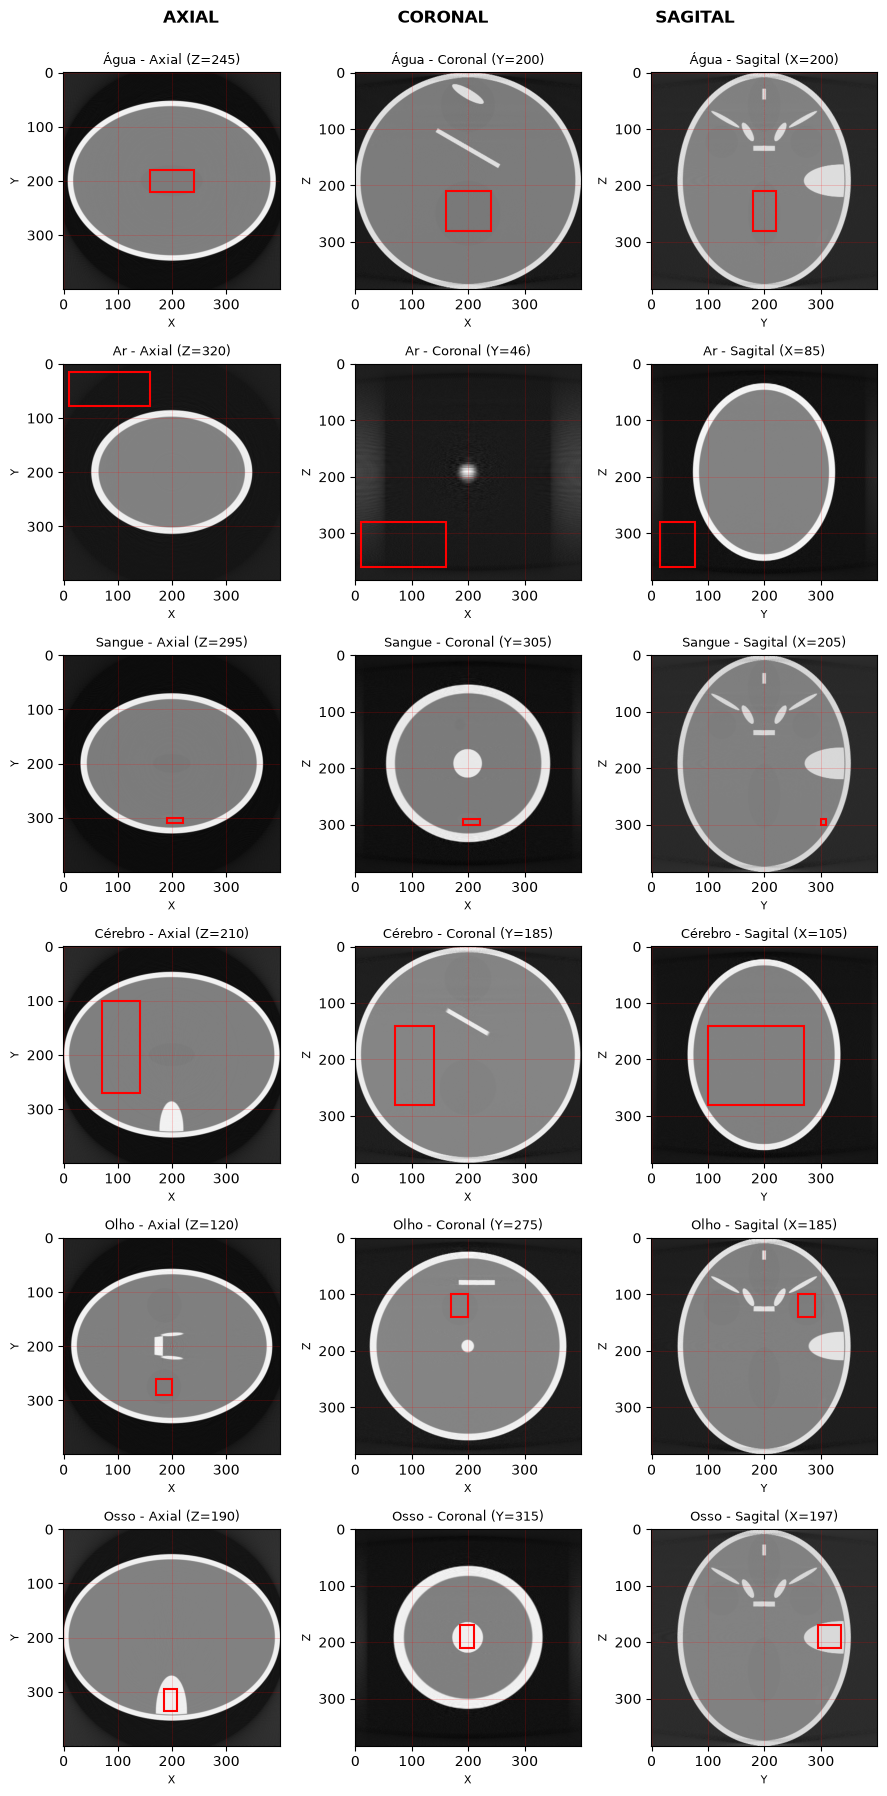

In [162]:
rois = {

    'Água': {
        'x': (160, 240),
        'y': (180, 220),
        'z': (210, 280)
    },

    'Ar': {
        'x': (10, 160),
        'y': (15, 77),
        'z': (280, 360)
    },

    'Sangue': {
        'x': (190, 220),
        'y': (300, 310),
        'z': (290, 300)
    },

    'Cérebro': {
        'x': (70, 140),
        'y': (100, 270),
        'z': (140, 280)
    },

    'Olho': {
        'x': (170, 200),
        'y': (260, 290),
        'z': (100, 140)
    },

    'Osso': {
        'x': (185, 210),
        'y': (295, 335),
        'z': (170, 210)
    }
}

masks = createRectMasks6Materials(
    imgFDK,
    rois
)

roi_agua = imgFDK[masks['Água'] == 1]
roi_ar = imgFDK[masks['Ar'] == 1]
roi_sangue = imgFDK[masks['Sangue'] == 1]
roi_cerebro = imgFDK[masks['Cérebro'] == 1]
roi_olho = imgFDK[masks['Olho'] == 1]
roi_osso = imgFDK[masks['Osso'] == 1]


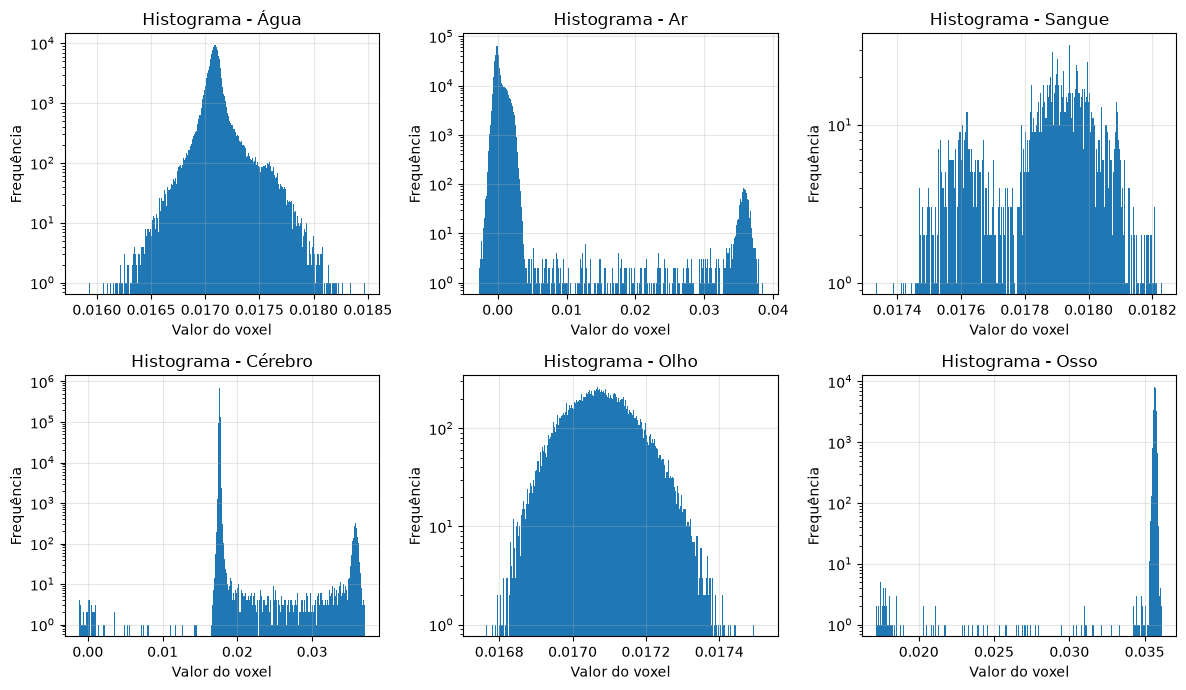

In [163]:
dados = [
    roi_agua,
    roi_ar,
    roi_sangue,
    roi_cerebro,
    roi_olho,
    roi_osso
]

titulos = [
    'Água',
    'Ar',
    'Sangue',
    'Cérebro',
    'Olho',
    'Osso'
]

fig, ax = plt.subplots(
    2, 3,
    figsize=(12, 7)
)

for a, dados_roi, titulo in zip(
    ax.ravel(),
    dados,
    titulos
):

    a.hist(
        dados_roi.flatten(),
        bins=512,
        log=True
    )

    a.set_xlabel('Valor do voxel')
    a.set_ylabel('Frequência')
    a.set_title(f'Histograma - {titulo}')
    a.grid(
        True,
        alpha=0.3
    )

plt.tight_layout()
plt.show()

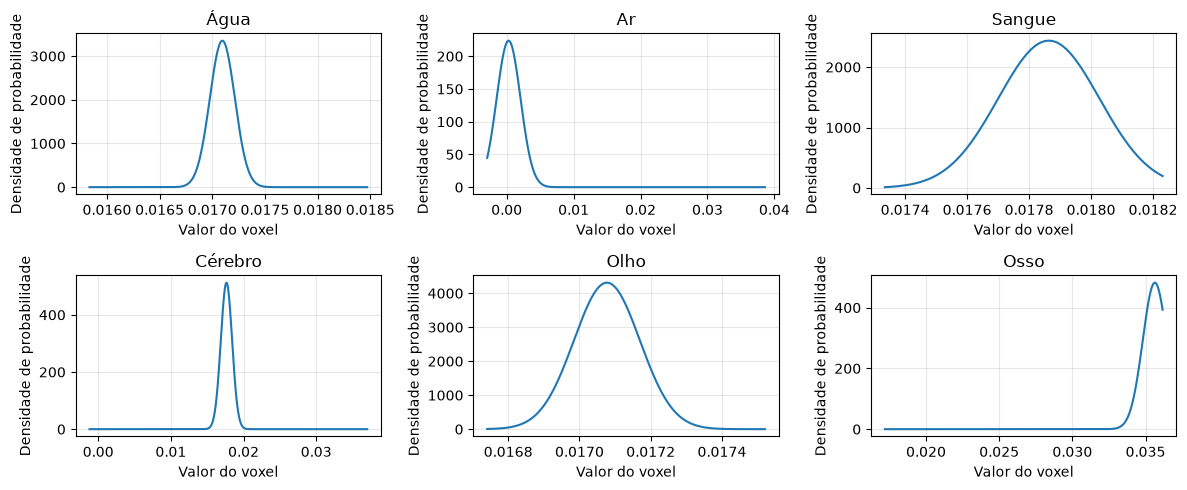

        VALORES DAS DISTRIBUIÇÕES
Água    : μ = 1.709537e-02 | σ = 1.189217e-04
Ar      : μ = 2.817271e-04 | σ = 1.782547e-03
Sangue  : μ = 1.786367e-02 | σ = 1.636969e-04
Cérebro : μ = 1.764830e-02 | σ = 7.782480e-04
Olho    : μ = 1.707693e-02 | σ = 9.253687e-05
Osso    : μ = 3.563653e-02 | σ = 8.272411e-04


In [164]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# AJUSTE GAUSSIANO
# ============================================================

def gaussiana(dados):

    dados = np.asarray(dados).flatten()

    mu = np.mean(dados)
    sigma = np.std(dados)

    x = np.linspace(dados.min(), dados.max(), 1000)

    gauss = (
        1 / (sigma * np.sqrt(2 * np.pi))
        * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))
    )

    return x, gauss, mu, sigma


# ============================================================
# ROIs
# ============================================================

dados = [
    roi_agua,
    roi_ar,
    roi_sangue,
    roi_cerebro,
    roi_olho,
    roi_osso
]

nomes = [
    'Água',
    'Ar',
    'Sangue',
    'Cérebro',
    'Olho',
    'Osso'
]


# ============================================================
# CALCULAR GAUSSIANAS
# ============================================================

resultados = [gaussiana(roi) for roi in dados]


# ============================================================
# MOSAICO DAS GAUSSIANAS
# ============================================================

fig, ax = plt.subplots(2, 3, figsize=(12, 5))

for a, nome, resultado in zip(ax.ravel(), nomes, resultados):

    x, g, mu, sigma = resultado

    a.plot(x, g)

    a.set_title(nome)
    a.set_xlabel('Valor do voxel')
    a.set_ylabel('Densidade de probabilidade')
    a.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# EXTRAIR μ E σ
# ============================================================

mu_agua, sigma_agua = resultados[0][2:]
mu_ar, sigma_ar = resultados[1][2:]
mu_sangue, sigma_sangue = resultados[2][2:]
mu_cerebro, sigma_cerebro = resultados[3][2:]
mu_olho, sigma_olho = resultados[4][2:]
mu_osso, sigma_osso = resultados[5][2:]


# ============================================================
# MOSTRAR μ E σ
# ============================================================

print('==============================================')
print('        VALORES DAS DISTRIBUIÇÕES')
print('==============================================')

print(f'Água    : μ = {mu_agua:.6e} | σ = {sigma_agua:.6e}')
print(f'Ar      : μ = {mu_ar:.6e} | σ = {sigma_ar:.6e}')
print(f'Sangue  : μ = {mu_sangue:.6e} | σ = {sigma_sangue:.6e}')
print(f'Cérebro : μ = {mu_cerebro:.6e} | σ = {sigma_cerebro:.6e}')
print(f'Olho    : μ = {mu_olho:.6e} | σ = {sigma_olho:.6e}')
print(f'Osso    : μ = {mu_osso:.6e} | σ = {sigma_osso:.6e}')

print('==============================================')


# ============================================================
# CONVERSÃO CT → HU
# ============================================================

def CT_to_HU(mu):

    return 1000 * (
        (mu - mu_agua) /
        (mu_agua - mu_ar)
    )




In [165]:
# ============================================================
# CONVERSÃO CT → HU
# ============================================================

def CT_to_HU(mu):

    return 1000 * (
        (mu - mu_agua) /
        (mu_agua - mu_ar)
    )


HU_agua = CT_to_HU(mu_agua)
HU_ar = CT_to_HU(mu_ar)
HU_sangue = CT_to_HU(mu_sangue)
HU_cerebro = CT_to_HU(mu_cerebro)
HU_olho = CT_to_HU(mu_olho)
HU_osso = CT_to_HU(mu_osso)


# ============================================================
# MOSTRAR HU
# ============================================================


print(f'Água    : {HU_agua:.2f} HU')
print(f'Ar      : {HU_ar:.2f} HU')
print(f'Sangue  : {HU_sangue:.2f} HU')
print(f'Cérebro : {HU_cerebro:.2f} HU')
print(f'Olho    : {HU_olho:.2f} HU')
print(f'Osso    : {HU_osso:.2f} HU')

Água    : 0.00 HU
Ar      : -1000.00 HU
Sangue  : 45.70 HU
Cérebro : 32.89 HU
Olho    : -1.10 HU
Osso    : 1102.75 HU


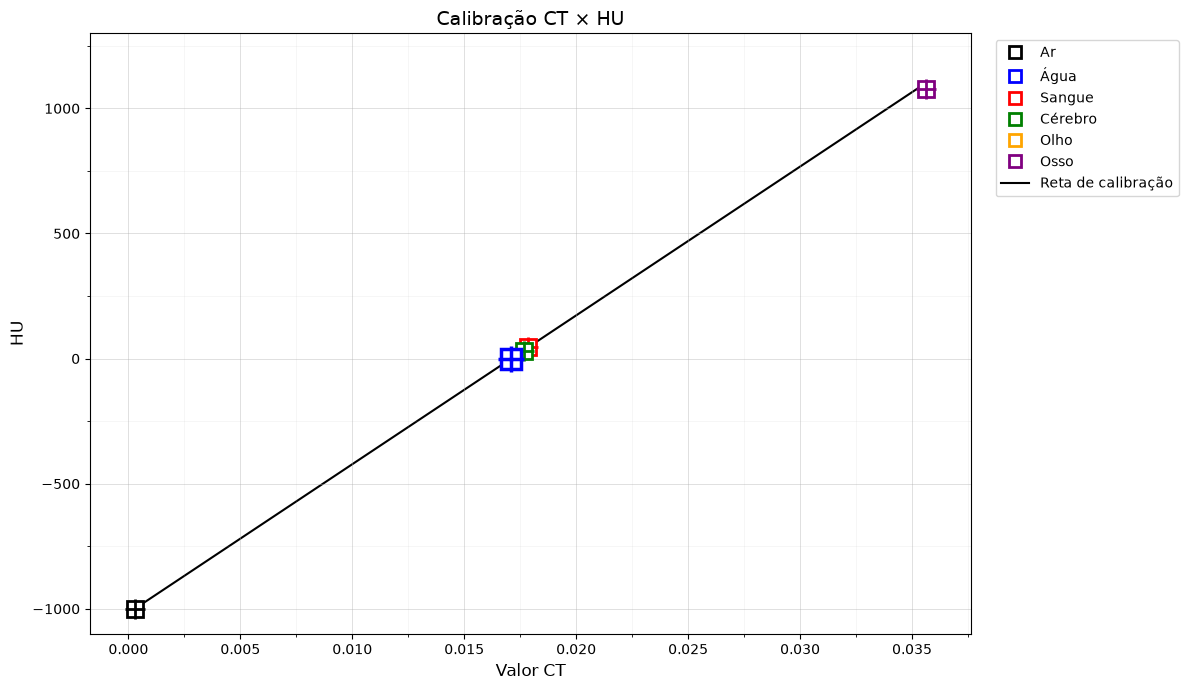

In [167]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator

# ============================================================
# DADOS
# ============================================================

CT = np.array([
    mu_ar,
    mu_agua,
    mu_sangue,
    mu_cerebro,
    mu_olho,
    mu_osso
])

HU = np.array([
    np.mean(roi_ar_HU),
    np.mean(roi_agua_HU),
    np.mean(roi_sangue_HU),
    np.mean(roi_cerebro_HU),
    np.mean(roi_olho_HU),
    np.mean(roi_osso_HU)
])

nomes = ['Ar', 'Água', 'Sangue', 'Cérebro', 'Olho', 'Osso']
cores = ['black', 'blue', 'red', 'green', 'orange', 'purple']

# ============================================================
# RETA DE CALIBRAÇÃO
# ============================================================

a = 1000 / (mu_agua - mu_ar)
b = -1000 * mu_agua / (mu_agua - mu_ar)

x = np.linspace(CT.min(), CT.max(), 500)
y = a * x + b

# ============================================================
# FIGURA
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

# ============================================================
# PONTOS
# ============================================================

for i in range(len(nomes)):

    ax.plot(
        CT[i],
        HU[i],
        marker='s',
        markersize=11,
        markerfacecolor='white',
        markeredgecolor=cores[i],
        markeredgewidth=2,
        linestyle='None'
    )

    ax.plot(
        CT[i],
        HU[i],
        marker='+',
        markersize=14,
        markeredgecolor=cores[i],
        markeredgewidth=2,
        linestyle='None'
    )

# Água desenhada por último e maior
ax.plot(
    mu_agua,
    np.mean(roi_agua_HU),
    marker='s',
    markersize=15,
    markerfacecolor='white',
    markeredgecolor='blue',
    markeredgewidth=2.5,
    linestyle='None',
    zorder=10
)

ax.plot(
    mu_agua,
    np.mean(roi_agua_HU),
    marker='+',
    markersize=19,
    markeredgecolor='blue',
    markeredgewidth=2.5,
    linestyle='None',
    zorder=11
)

# ============================================================
# RETA
# ============================================================

ax.plot(
    x,
    y,
    color='black',
    linewidth=1.5,
    zorder=1
)

# ============================================================
# EIXOS E ESCALA
# ============================================================

ax.set_xlabel('Valor CT', fontsize=12)
ax.set_ylabel('HU', fontsize=12)
ax.set_title('Calibração CT × HU', fontsize=14)

ax.set_xlim(CT.min() - 0.002, CT.max() + 0.002)
ax.set_ylim(-1100, 1300)

# ============================================================
# GRADE
# ============================================================

ax.grid(which='major', linewidth=0.7, alpha=0.4)
ax.grid(which='minor', linewidth=0.4, alpha=0.2)

ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

# ============================================================
# LEGENDA
# ============================================================

handles = []

for nome, cor in zip(nomes, cores):
    handles.append(
        Line2D(
            [0], [0],
            marker='s',
            markerfacecolor='white',
            markeredgecolor=cor,
            markeredgewidth=2,
            markersize=9,
            linestyle='None',
            label=nome
        )
    )

handles.append(
    Line2D(
        [0], [0],
        color='black',
        linewidth=1.5,
        label='Reta de calibração'
    )
)

ax.legend(
    handles=handles,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    fontsize=10
)

plt.tight_layout()
plt.show()

In [168]:
imgHU = 1000 * ((imgFDK - mu_agua) / (mu_agua - mu_ar))

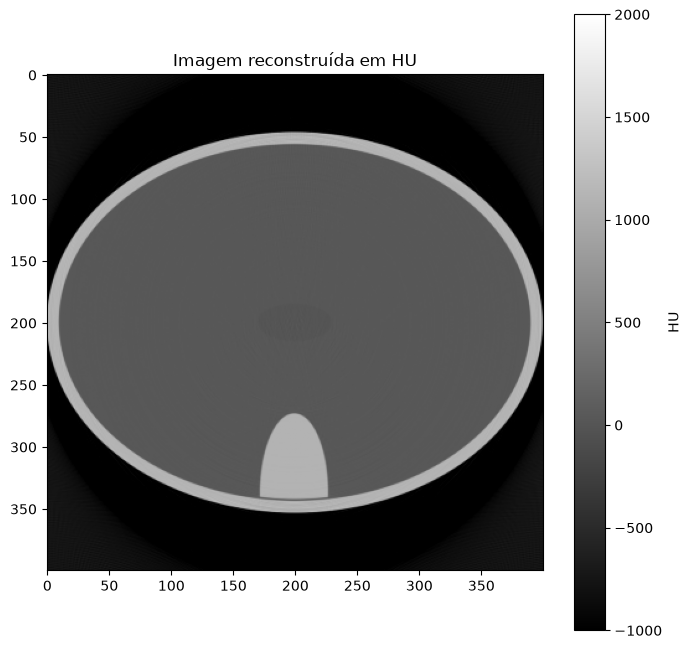

In [169]:
# ============================================================
# VISUALIZAÇÃO DA IMAGEM EM HU
# ============================================================

slice_z = imgHU.shape[2] // 2

plt.figure(figsize=(8, 8))

plt.imshow(
    imgHU[slice_z],
    cmap="gray",
    vmin=-1000,
    vmax=2000
)

plt.colorbar(label="HU")
plt.title("Imagem reconstruída em HU")

plt.show()

In [170]:
np.savez(
    "/mnt/d/Iniciacao_cientifica/head_phantom/volume2_hu.npz",
    volume=imgHU
)